<a href="https://colab.research.google.com/github/amna-alii/CV-Lab02/blob/main/Task2_Image_Filtering_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

**Objective:** investigate how spatial-domain image filters affect the performance of the
**best 3 pretrained models identified in Lab Activity 1 (Task 01)**.

- **Model 1:** EfficientNet-B0 (96.0% val accuracy in Task 01)
- **Model 2:** ResNet18 (90.0% val accuracy in Task 01)
- **Model 3:** ResNet50 (89.0% val accuracy in Task 01)

**Dataset:** same 5-class HAM10000-derived subset used in Task 01
(Melanoma, Melanocytic nevus, Benign keratosis, Dermatofibroma, Vascular lesion).

**Filters compared against a no-filter baseline:** Average/Mean, Gaussian, Median, Sharpening, Sobel edge.

**How to use in Colab:**
1. Runtime → Change runtime type → GPU (T4).
2. Run the Setup cell, then upload the same dataset zip you used in Task 01.
3. Run all cells top to bottom. This runs **18 training experiments** (3 models × 6 conditions),
   so budget real time for it — lower `EPOCHS` first if you just want to test the pipeline.
4. The final comparison table + all required plots are generated automatically and exported.
5. The "Questions to Answer" section at the end is left as **markdown placeholders only** —
   fill those in yourself once you've reviewed the real results.

## 1. Setup — install packages & imports

In [2]:
!pip install -q thop opencv-python-headless

In [3]:
import os, glob, shutil, time, zipfile, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from PIL import Image

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, balanced_accuracy_score,
                              classification_report, roc_curve, auc)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## 2. Dataset preparation

Upload the **same dataset zip** used in Task 01 (the one with `Split_smol/train/<class>` and
`Split_smol/val/<class>` folders).

In [ ]:
from google.colab import files

uploaded = files.upload()   # choose your dataset zip (same one as Task 01)
zip_name = list(uploaded.keys())[0]

extract_dir = "dataset_full"
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

base_src = None
for root, dirs, _files in os.walk(extract_dir):
    if "train" in dirs and "val" in dirs:
        base_src = root
        break
print("Dataset root found at:", base_src)

In [ ]:
SELECTED_CLASSES = [
    "Melanoma",
    "Melanocytic nevus",
    "Benign keratosis",
    "Dermatofibroma",
    "Vascular lesion",
]

base_dst = "dataset_5class"
for split in ["train", "val"]:
    for cls in SELECTED_CLASSES:
        src = os.path.join(base_src, split, cls)
        dst = os.path.join(base_dst, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in glob.glob(os.path.join(src, "*")):
            shutil.copy(f, dst)

print("Image counts per class:")
counts = {}
for split in ["train", "val"]:
    for cls in SELECTED_CLASSES:
        n = len(os.listdir(os.path.join(base_dst, split, cls)))
        counts[(split, cls)] = n
        print(f"  {split:5s} / {cls:25s}: {n}")

### Class distribution (required in Additional Analysis)

               Class  Train  Val  Total
0           Melanoma     80   20    100
1  Melanocytic nevus     80   20    100
2   Benign keratosis     80   20    100
3     Dermatofibroma     80   20    100
4    Vascular lesion     80   20    100


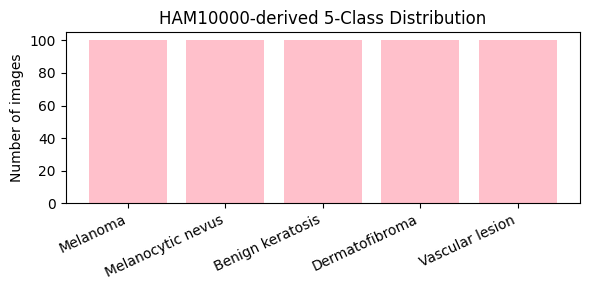

In [9]:
dist_df = pd.DataFrame(
    [[cls, counts[("train", cls)], counts[("val", cls)]] for cls in SELECTED_CLASSES],
    columns=["Class", "Train", "Val"]
)
dist_df["Total"] = dist_df["Train"] + dist_df["Val"]
print(dist_df)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(dist_df["Class"], dist_df["Total"], color="pink")
ax.set_ylabel("Number of images")
ax.set_title("HAM10000-derived 5-Class Distribution")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 3. Image filtering functions

Each filter is implemented with OpenCV and wrapped as a torchvision-compatible transform that
operates on a PIL image before it is converted to a tensor. Sobel produces an edge map which is
replicated across 3 channels so it can still be fed into an RGB-pretrained backbone.

In [ ]:
def apply_average(img_np):
    return cv2.blur(img_np, (5, 5))

def apply_gaussian(img_np):
    return cv2.GaussianBlur(img_np, (5, 5), 0)

def apply_median(img_np):
    return cv2.medianBlur(img_np, 5)

def apply_sharpen(img_np):
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])
    return cv2.filter2D(img_np, -1, kernel)

def apply_sobel(img_np):
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.uint8(255 * mag / (mag.max() + 1e-8))
    return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)

FILTER_FUNCS = {
    "No Filter": None,
    "Average": apply_average,
    "Gaussian": apply_gaussian,
    "Median": apply_median,
    "Sharpening": apply_sharpen,
    "Sobel": apply_sobel,
}

class FilterTransform:
    """Applies a numpy/OpenCV filter function to a PIL image."""
    def __init__(self, filter_fn):
        self.filter_fn = filter_fn

    def __call__(self, pil_img):
        if self.filter_fn is None:
            return pil_img
        img_np = np.array(pil_img.convert("RGB"))
        filtered = self.filter_fn(img_np)
        return Image.fromarray(filtered)

### Original vs. filtered image examples (required in Additional Analysis)

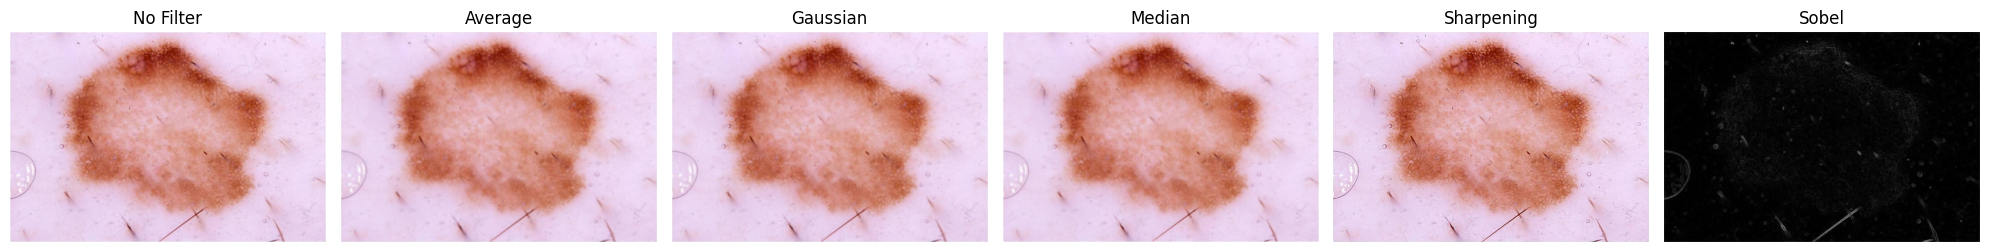

In [7]:
sample_path = glob.glob(os.path.join(base_dst, "train", SELECTED_CLASSES[0], "*"))[0]
sample_img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, len(FILTER_FUNCS), figsize=(20, 4))
for ax, (fname, ffn) in zip(axes, FILTER_FUNCS.items()):
    transformed = FilterTransform(ffn)(sample_img)
    ax.imshow(transformed)
    ax.set_title(fname)
    ax.axis("off")
plt.tight_layout()
plt.savefig("filter_examples.png", dpi=150)
plt.show()

## 4. Data loaders (parameterized by filter)

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = len(SELECTED_CLASSES)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_loaders(filter_name):
    filter_fn = FILTER_FUNCS[filter_name]

    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        FilterTransform(filter_fn),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        FilterTransform(filter_fn),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    train_ds = datasets.ImageFolder(os.path.join(base_dst, "train"), transform=train_tf)
    val_ds   = datasets.ImageFolder(os.path.join(base_dst, "val"),   transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader, train_ds.classes

_, _, class_names = make_loaders("No Filter")
print("Class order:", list(enumerate(class_names)))

Class order: [(0, 'Benign keratosis'), (1, 'Dermatofibroma'), (2, 'Melanocytic nevus'), (3, 'Melanoma'), (4, 'Vascular lesion')]


## 5. Model loading

In [ ]:
BEST_MODELS = ["EfficientNet-B0", "ResNet18", "ResNet50"]   # from Task 01 results

def build_model(name, num_classes):
    if name == "ResNet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "EfficientNet-B0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

## 6. Training & evaluation functions

Same settings (epochs, optimizer, LR, batch size) are reused for every model/filter combination so the comparison stays fair.

In [13]:
EPOCHS = 8       # keep identical across ALL runs for a fair comparison; raise if time allows
LR = 1e-4

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"    epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f} train_acc={train_acc:.3f}"
              f"  val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    return model, history


def evaluate_model(model, loader, num_classes):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(y.numpy())
            all_probs.extend(probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc      = accuracy_score(all_labels, all_preds) * 100
    prec     = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    rec      = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1_w     = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    bal_acc  = balanced_accuracy_score(all_labels, all_preds) * 100
    try:
        y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
        auc_score = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr') * 100
    except Exception:
        auc_score = np.nan

    metrics = {
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "F1-score": f1_w, "Macro-F1": f1_macro, "AUC": auc_score,
        "Balanced Accuracy": bal_acc,
    }
    return metrics, all_labels, all_preds, all_probs

## 7. Baseline experiment + filtered experiments (main loop)

Runs all 3 models × 6 conditions (No Filter + 5 filters) = 18 experiments total, using identical
settings throughout. Results, histories, confusion matrices, and probability arrays are stored for
the visualization and comparative-analysis sections below.

In [14]:
FILTER_ORDER = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

all_results = []          # rows for the final comparison table
all_histories = {}        # (model, filter) -> history dict
all_confmats = {}         # (model, filter) -> confusion matrix
all_roc_data = {}         # (model, filter) -> (labels, probs) for ROC curves

for model_name in BEST_MODELS:
    for filter_name in FILTER_ORDER:
        print(f"\n=== {model_name} | {filter_name} ===")
        train_loader, val_loader, _ = make_loaders(filter_name)

        model = build_model(model_name, NUM_CLASSES)
        model, history = train_model(model, train_loader, val_loader)
        metrics, labels, preds, probs = evaluate_model(model, val_loader, NUM_CLASSES)

        print(f"  -> {metrics}")

        all_results.append({
            "Model": model_name,
            "Filter": filter_name,
            **{k: round(v, 2) for k, v in metrics.items()}
        })
        all_histories[(model_name, filter_name)] = history
        all_confmats[(model_name, filter_name)] = confusion_matrix(labels, preds)
        all_roc_data[(model_name, filter_name)] = (labels, probs)

        del model
        torch.cuda.empty_cache()

results_df = pd.DataFrame(all_results)
results_df.to_csv("task2_filter_comparison_results.csv", index=False)
print("\n=== FULL COMPARISON TABLE ===")
results_df


=== EfficientNet-B0 | No Filter ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


    epoch 1/8  train_loss=1.4590 train_acc=0.470  val_loss=1.2365 val_acc=0.690
    epoch 2/8  train_loss=1.1166 train_acc=0.705  val_loss=0.9150 val_acc=0.730
    epoch 3/8  train_loss=0.7882 train_acc=0.775  val_loss=0.6700 val_acc=0.820
    epoch 4/8  train_loss=0.6292 train_acc=0.820  val_loss=0.5066 val_acc=0.870
    epoch 5/8  train_loss=0.4415 train_acc=0.865  val_loss=0.4060 val_acc=0.900
    epoch 6/8  train_loss=0.3555 train_acc=0.905  val_loss=0.3368 val_acc=0.920
    epoch 7/8  train_loss=0.3079 train_acc=0.912  val_loss=0.3173 val_acc=0.910
    epoch 8/8  train_loss=0.1937 train_acc=0.960  val_loss=0.2776 val_acc=0.910
  -> {'Accuracy': 91.0, 'Precision': 91.54545454545455, 'Recall': 90.99999999999999, 'F1-score': 90.96825396825398, 'Macro-F1': 90.96825396825396, 'AUC': np.float64(99.41250000000001), 'Balanced Accuracy': np.float64(90.99999999999999)}

=== EfficientNet-B0 | Average ===
    epoch 1/8  train_loss=1.4483 train_acc=0.458  val_loss=1.1691 val_acc=0.690
    epoc

100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


    epoch 1/8  train_loss=1.0133 train_acc=0.593  val_loss=0.4674 val_acc=0.820
    epoch 2/8  train_loss=0.4301 train_acc=0.853  val_loss=0.3597 val_acc=0.860
    epoch 3/8  train_loss=0.2617 train_acc=0.902  val_loss=0.3095 val_acc=0.860
    epoch 4/8  train_loss=0.1918 train_acc=0.938  val_loss=0.2854 val_acc=0.890
    epoch 5/8  train_loss=0.1582 train_acc=0.945  val_loss=0.3938 val_acc=0.860
    epoch 6/8  train_loss=0.0875 train_acc=0.980  val_loss=0.3424 val_acc=0.840
    epoch 7/8  train_loss=0.0883 train_acc=0.980  val_loss=0.4439 val_acc=0.820
    epoch 8/8  train_loss=0.0773 train_acc=0.985  val_loss=0.4199 val_acc=0.830
  -> {'Accuracy': 83.0, 'Precision': 84.11764705882354, 'Recall': 83.0, 'F1-score': 83.25367472735894, 'Macro-F1': 83.25367472735896, 'AUC': np.float64(96.9125), 'Balanced Accuracy': np.float64(83.0)}

=== ResNet18 | Average ===
    epoch 1/8  train_loss=0.9917 train_acc=0.630  val_loss=0.5930 val_acc=0.810
    epoch 2/8  train_loss=0.3951 train_acc=0.853  v

100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


    epoch 1/8  train_loss=1.4186 train_acc=0.522  val_loss=1.0401 val_acc=0.750
    epoch 2/8  train_loss=0.8013 train_acc=0.805  val_loss=0.5481 val_acc=0.800
    epoch 3/8  train_loss=0.4735 train_acc=0.850  val_loss=0.4504 val_acc=0.850
    epoch 4/8  train_loss=0.2924 train_acc=0.892  val_loss=0.3364 val_acc=0.880
    epoch 5/8  train_loss=0.2296 train_acc=0.927  val_loss=0.3538 val_acc=0.850
    epoch 6/8  train_loss=0.1640 train_acc=0.948  val_loss=0.2665 val_acc=0.890
    epoch 7/8  train_loss=0.1152 train_acc=0.963  val_loss=0.2582 val_acc=0.880
    epoch 8/8  train_loss=0.0772 train_acc=0.975  val_loss=0.2788 val_acc=0.910
  -> {'Accuracy': 91.0, 'Precision': 91.5, 'Recall': 90.99999999999999, 'F1-score': 90.91919191919192, 'Macro-F1': 90.91919191919192, 'AUC': np.float64(98.475), 'Balanced Accuracy': np.float64(90.99999999999999)}

=== ResNet50 | Average ===
    epoch 1/8  train_loss=1.4733 train_acc=0.472  val_loss=1.2128 val_acc=0.640
    epoch 2/8  train_loss=0.9524 train_

,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,AUC,Balanced Accuracy
0,EfficientNet-B0,No Filter,91.0,91.55,91.0,90.97,90.97,99.41,91.0
1,EfficientNet-B0,Average,81.0,81.17,81.0,80.35,80.35,97.79,81.0
2,EfficientNet-B0,Gaussian,88.0,88.72,88.0,88.01,88.01,98.46,88.0
3,EfficientNet-B0,Median,84.0,83.82,84.0,83.72,83.72,98.28,84.0
4,EfficientNet-B0,Sharpening,91.0,91.81,91.0,90.86,90.86,99.56,91.0
5,EfficientNet-B0,Sobel,80.0,80.79,80.0,79.81,79.81,95.95,80.0
6,ResNet18,No Filter,83.0,84.12,83.0,83.25,83.25,96.91,83.0
7,ResNet18,Average,89.0,89.71,89.0,89.11,89.11,97.48,89.0
8,ResNet18,Gaussian,89.0,88.95,89.0,88.70,88.70,96.60,89.0
9,ResNet18,Median,90.0,90.71,90.0,89.88,89.88,97.70,90.0


## 8. Visualization

### 8.1 Confusion matrices (one grid per model, all 6 filter conditions)

In [ ]:
for model_name in BEST_MODELS:
    fig, axes = plt.subplots(1, len(FILTER_ORDER), figsize=(24, 4))
    fig.suptitle(f"Confusion Matrices — {model_name}", y=1.05, fontsize=14)
    for ax, filter_name in zip(axes, FILTER_ORDER):
        cm = all_confmats[(model_name, filter_name)]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(filter_name, fontsize=10)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(class_names, rotation=90, fontsize=6)
        ax.set_yticklabels(class_names, fontsize=6)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.tight_layout()
    plt.savefig(f"confusion_matrices_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 8.2 Training / validation accuracy curves

In [ ]:
for model_name in BEST_MODELS:
    fig, ax = plt.subplots(figsize=(8, 5))
    for filter_name in FILTER_ORDER:
        h = all_histories[(model_name, filter_name)]
        ax.plot(range(1, EPOCHS+1), h["val_acc"], marker='o', label=filter_name)
    ax.set_title(f"Validation Accuracy per Epoch — {model_name}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"accuracy_curves_{model_name}.png", dpi=150)
    plt.show()

### 8.3 Training / validation loss curves

In [ ]:
for model_name in BEST_MODELS:
    fig, ax = plt.subplots(figsize=(8, 5))
    for filter_name in FILTER_ORDER:
        h = all_histories[(model_name, filter_name)]
        ax.plot(range(1, EPOCHS+1), h["val_loss"], marker='o', label=filter_name)
    ax.set_title(f"Validation Loss per Epoch — {model_name}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Loss")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"loss_curves_{model_name}.png", dpi=150)
    plt.show()

### 8.4 ROC curves (one-vs-rest, macro) per model/filter

In [ ]:
for model_name in BEST_MODELS:
    fig, ax = plt.subplots(figsize=(7, 6))
    for filter_name in FILTER_ORDER:
        labels, probs = all_roc_data[(model_name, filter_name)]
        y_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
        fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{filter_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f"Micro-average ROC — {model_name}")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"roc_curves_{model_name}.png", dpi=150)
    plt.show()

### 8.5 Per-class precision, recall, F1-score (baseline vs. each filter)

In [ ]:
per_class_rows = []
for model_name in BEST_MODELS:
    for filter_name in FILTER_ORDER:
        labels, probs = all_roc_data[(model_name, filter_name)]
        preds = probs.argmax(axis=1)
        report = classification_report(labels, preds, target_names=class_names,
                                         output_dict=True, zero_division=0)
        for cls in class_names:
            per_class_rows.append({
                "Model": model_name, "Filter": filter_name, "Class": cls,
                "Precision": round(report[cls]["precision"]*100, 2),
                "Recall": round(report[cls]["recall"]*100, 2),
                "F1-score": round(report[cls]["f1-score"]*100, 2),
            })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv("task2_per_class_metrics.csv", index=False)
per_class_df

## 9. Comparative analysis

In [ ]:
# Change relative to each model's own "No Filter" baseline, for every metric
comparison_rows = []
for model_name in BEST_MODELS:
    baseline = results_df[(results_df.Model == model_name) & (results_df.Filter == "No Filter")].iloc[0]
    for filter_name in FILTER_ORDER:
        if filter_name == "No Filter":
            continue
        row = results_df[(results_df.Model == model_name) & (results_df.Filter == filter_name)].iloc[0]
        comparison_rows.append({
            "Model": model_name,
            "Filter": filter_name,
            "Δ Accuracy": round(row["Accuracy"] - baseline["Accuracy"], 2),
            "Δ Macro-F1": round(row["Macro-F1"] - baseline["Macro-F1"], 2),
            "Δ Balanced Accuracy": round(row["Balanced Accuracy"] - baseline["Balanced Accuracy"], 2),
            "Δ AUC": round(row["AUC"] - baseline["AUC"], 2),
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("task2_delta_vs_baseline.csv", index=False)
print("=== Change vs. each model's No-Filter baseline ===")
comparison_df

In [ ]:
# Which filter produces the biggest average swing (positive or negative) across all 3 models?
swing = comparison_df.groupby("Filter")["Δ Accuracy"].apply(lambda s: s.abs().mean()).sort_values(ascending=False)
print("Average |Δ Accuracy| across all 3 models, by filter:")
print(swing)

## 10. Download all results

Downloads the CSVs and PNG figures generated above so you can attach them to your report and push
them to GitHub.

In [ ]:
from google.colab import files as colab_files
import glob as _glob

outputs = (
    _glob.glob("*.csv") + _glob.glob("*.png")
)
for f in outputs:
    colab_files.download(f)
print("Downloaded:", outputs)

## 11. Questions to Answer

*(Left intentionally blank — fill these in after reviewing the real experimental results above.)*

1. Which three pretrained models performed best in Lab Activity 1?
2. How does filtering affect each of the three models?
3. Which filter produces the greatest change compared with the unfiltered baseline?
4. Does the effect of a filter remain consistent across all three models?
5. Does filtering improve or decrease macro-F1 and balanced accuracy?
6. Which lesion classes are most affected by filtering?
7. Why might smoothing remove useful lesion texture or morphological information?
8. Why might sharpening or edge detection help or hurt classification?
9. What is the difference between convolution and correlation?
10. Based on your results, explain the relationship between classical image processing and deep-learning-based feature extraction.